In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Species"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
from sklearn.preprocessing import LabelEncoder

In [4]:
encoder = LabelEncoder()

In [5]:
df['Species'] = encoder.fit_transform(df['Species'])

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df = df[df['Species'] != 0][['sepal width (cm)','petal length (cm)','Species']]

In [9]:
df.head()

,sepal width (cm),petal length (cm),Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

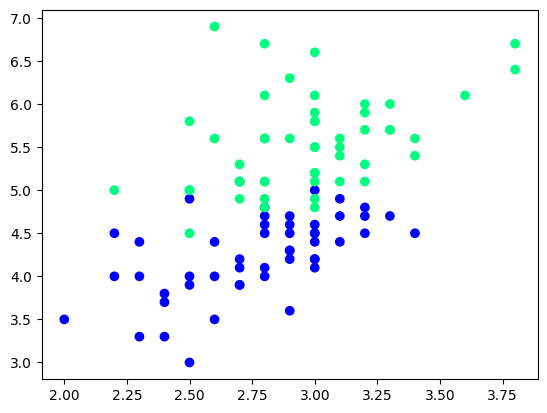

In [11]:
plt.scatter(df['sepal width (cm)'], df['petal length (cm)'], c = df['Species'],cmap='winter')

In [12]:
# Taking only 10 rows for training
df = df.sample(100) # randomly took 100 samples 
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [14]:
df_train

,sepal width (cm),petal length (cm),Species
65,3.1,4.4,1
120,3.2,5.7,2
109,3.6,6.1,2
87,2.3,4.4,1
68,2.2,4.5,1
60,2.0,3.5,1
149,3.0,5.1,2
129,3.0,5.8,2
144,3.3,5.7,2
85,3.4,4.5,1


In [15]:
df_val

,sepal width (cm),petal length (cm),Species
77,3.0,5.0,1
103,2.9,5.6,2
62,2.2,4.0,1
90,2.6,4.4,1
52,3.1,4.9,1


In [16]:
df_test

,sepal width (cm),petal length (cm),Species
95,3.0,4.2,1
145,3.0,5.2,2
89,2.5,4.0,1
140,3.1,5.6,2
76,2.8,4.8,1


In [18]:
X_test = df_val.iloc[:,0:2].values # we made the date into arrays
y_test = df_val.iloc[:,-1].values

## Case 1 - Bagging

In [20]:
# Data for tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),Species
144,3.3,5.7,2
60,2.0,3.5,1
60,2.0,3.5,1
109,3.6,6.1,2
149,3.0,5.1,2
87,2.3,4.4,1
109,3.6,6.1,2
87,2.3,4.4,1


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [22]:
dt_bag1 = DecisionTreeClassifier()

In [24]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

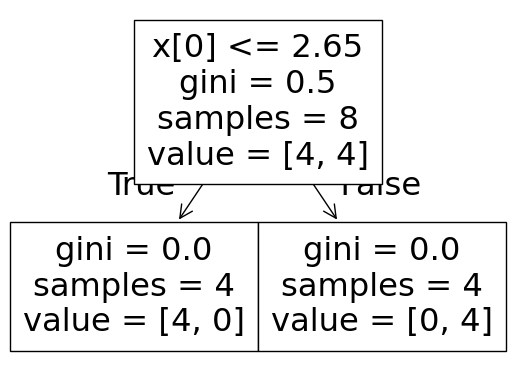

C:\Users\lshik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\lshik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


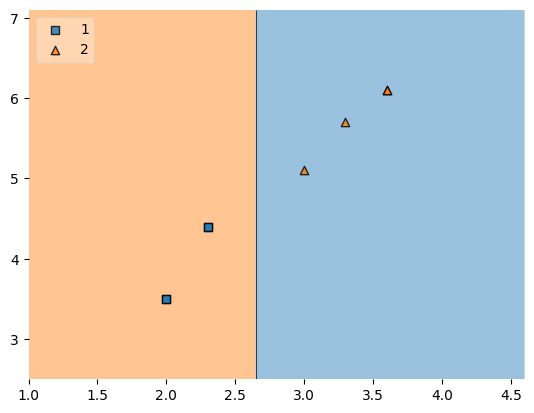

In [25]:
evaluate(dt_bag1,X,y)

In [29]:
# Data for tree 2
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),Species
85,3.4,4.5,1
149,3.0,5.1,2
129,3.0,5.8,2
68,2.2,4.5,1
149,3.0,5.1,2
120,3.2,5.7,2
87,2.3,4.4,1
65,3.1,4.4,1


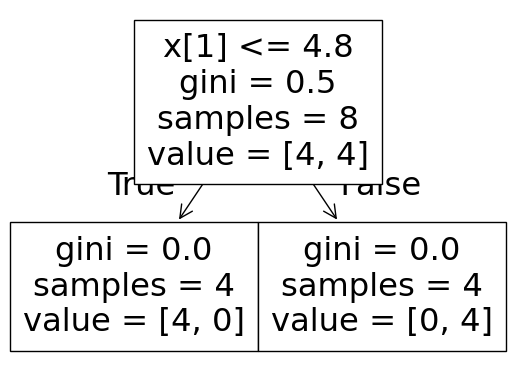

C:\Users\lshik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\lshik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


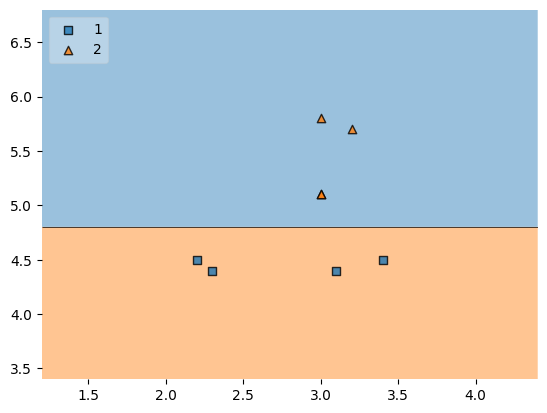

In [30]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [31]:
# Data for tree 2
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),Species
120,3.2,5.7,2
87,2.3,4.4,1
129,3.0,5.8,2
144,3.3,5.7,2
144,3.3,5.7,2
120,3.2,5.7,2
60,2.0,3.5,1
85,3.4,4.5,1


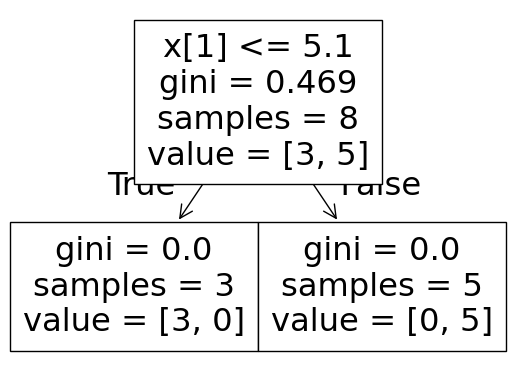

C:\Users\lshik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\lshik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


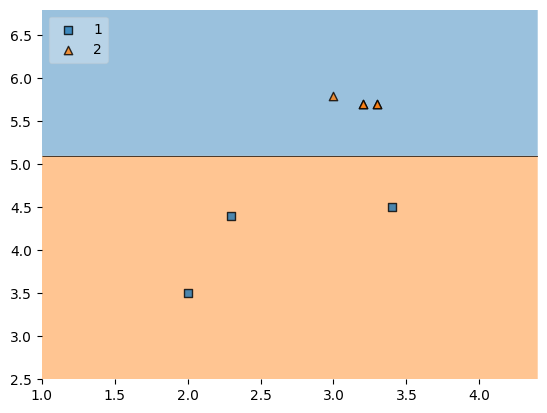

In [32]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [33]:
df_test

,sepal width (cm),petal length (cm),Species
95,3.0,4.2,1
145,3.0,5.2,2
89,2.5,4.0,1
140,3.1,5.6,2
76,2.8,4.8,1


In [39]:
print("Predictor 1",dt_bag1.predict(np.array([3.1,5.6]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([3.1,5.6]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([3.1,5.6]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


C:\Users\lshik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\lshik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\lshik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
